# Data Preparation

### Purpose:
 - Parse ICDAR word.xml files into a standard annotation dataframe.
 - Save annotations to JSON for reuse in baseline + fine-tuning notebooks.
 - Load a German word list (for later synthetic image generation).

### Inputs:
 - Datasets/train/word.xml
 - Datasets/test/word.xml
 - Datasets/German-words-5000-words.json

### Outputs:
 - Datasets/Annotated_files/iiit5k_train_annotations.json
 - Datasets/Annotated_files/iiit5k_test_annotations.json

### Notes:
 - Paths are relative to repo root (../Datasets when running from src/).

In [1]:
import os
import xml.etree.ElementTree as ET
import pandas as pd
from PIL import Image
from IPython.display import display
import json

In [2]:
## Path Setup

Base_dir = ".."
Dataset_dir = os.path.join(Base_dir, "Datasets")

Train_dir = os.path.join(Dataset_dir, "train")
Test_dir = os.path.join(Dataset_dir, "test")

train_xml = os.path.join(Train_dir, "word.xml")
test_xml = os.path.join(Test_dir, "word.xml")

german_json = os.path.join(Dataset_dir, "German-words-5000-words.json")

In [3]:
## Function to parse and return the dataframe

def parse_iiit_xml(xml_path, base_folder):
    """Parse ICDAR `word.xml` and return a dataframe of image paths + labels.

    Why:
        The ICDAR dataset stores annotations in an XML file that references images
        via relative paths and labels via the `tag` attribute. This function standardizes
        them into a dataframe with:
            - image_path: absolute/relative resolved path to the image file
            - label: ground-truth word

    Args:
        xml_path: Path to word.xml (train or test).
        base_folder: Folder that contains the images referenced by the XML.

    Returns:
        pd.DataFrame with columns: ["image_path", "label"]
    """
    tree = ET.parse(xml_path)
    root = tree.getroot()

    records = []
    for img in root.iter("image"):
        rel_path = img.attrib["file"]    
        label = img.attrib["tag"]     

        full_path = os.path.join(base_folder, rel_path)
        records.append({"image_path": full_path, "label": label})

    return pd.DataFrame(records)


In [4]:
train_df = parse_iiit_xml(train_xml, Train_dir)
test_df  = parse_iiit_xml(test_xml, Test_dir)

len(train_df), len(test_df)

(1156, 331)

In [5]:
train_df.head()

,image_path,label
0,../Datasets/train/word/1/1.jpg,self
1,../Datasets/train/word/1/2.jpg,adhesive
2,../Datasets/train/word/1/3.jpg,address
3,../Datasets/train/word/1/4.jpg,labels
4,../Datasets/train/word/1/5.jpg,36


SOAP ../Datasets/train/word/3/288.jpg


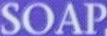

In [6]:
sample = train_df.sample(100).iloc[0]
print(sample["label"], sample["image_path"])

img = Image.open(sample["image_path"]).convert("RGB")
display(img)


### Save annotation files

In [10]:
annot_dir = os.path.join(Dataset_dir, "Annotated_files")  
os.makedirs(annot_dir, exist_ok=True)

train_ann_path = os.path.join(annot_dir, "iiit5k_train_annotations.json")
test_ann_path  = os.path.join(annot_dir, "iiit5k_test_annotations.json")

train_df.to_json(train_ann_path, orient="records", force_ascii=False, indent=2)
test_df.to_json(test_ann_path, orient="records", force_ascii=False, indent=2)

train_ann_path, test_ann_path


('../Datasets/Annotated_files/iiit5k_train_annotations.json',
 '../Datasets/Annotated_files/iiit5k_test_annotations.json')

### Load the German word list

In [8]:
# This word list is used later to generate synthetic word images containing
# German-specific characters (ä, ö, ü, ß), which are underrepresented in IIIT-5K.
# The source JSON may have different structures (list, {"words": [...]}, or dict),
# so we normalize it into a list of strings.


German_json = os.path.join(Dataset_dir, "German-words-5000-words.json")
with open(German_json, "r", encoding="utf-8") as f:
    german_data = json.load(f)
if isinstance(german_data, list):
    german_words = german_data
elif "words" in german_data:
    german_words = german_data["words"]
else:
    german_words = list(german_data.values())

len(german_words), german_words[:10]


(4999,
 ['Abbaumaschinen',
  'Abbauorte',
  'Abbausituationen',
  'Abendwache',
  'Abfallens',
  'Abfalltasche',
  'Abfallvermeidungen',
  'Abfallvolumen',
  'Abfertigungsbeamten',
  'Abfertigungsfeld'])

In [1]:
import sys
print(sys.version)


3.11.13 | packaged by conda-forge | (main, Jun  4 2025, 14:48:23) [GCC 13.3.0]
